In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# ==========================================
# Set your root directory
# ==========================================
root_dir = '/Volumes/Backup Plus/Experiment_results/332_notum_analysis/Experiment'

# ==========================================
# Find all npz files
# ==========================================
sample_data = {}

for condition in os.listdir(root_dir):

    condition_path = os.path.join(root_dir, condition)

    if not os.path.isdir(condition_path):
        continue

    for image_folder in os.listdir(condition_path):

        image_path = os.path.join(condition_path, image_folder)

        if not os.path.isdir(image_path):
            continue

        npz_path = os.path.join(
            image_path,
            "565",
            "results",
            "assignment_results_of_spots_in_nuclei.npz"
        )

        if not os.path.exists(npz_path):
            print(f"Missing: {npz_path}")
            continue

        sample_name = f"{condition}_{image_folder}"

        data = np.load(npz_path, allow_pickle=True)

        print(sample_name)
        print("Keys:", data.files)

        # ----------------------------------
        # OPTION 1:
        # If npz contains only one array
        # ----------------------------------
        arr = data[data.files[0]]

        # Flatten if needed
        arr = np.ravel(arr)

        sample_data[sample_name] = arr

# ==========================================
# Save CSV
# ==========================================
df = pd.DataFrame(
    {k: pd.Series(v) for k, v in sample_data.items()}
)

csv_path = os.path.join(root_dir, "all_samples.csv")
df.to_csv(csv_path, index=False)

0h_Amputation_Image1
Keys: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8']
0h_Amputation_Image2
Keys: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8']
6h_Incision_Image1
Keys: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9', 'arr_10', 'arr_11']
6h_Incision_Image2
Keys: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7']
0h_Incision_Image1
Keys: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9']
0h_Incision_Image2
Keys: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8']
0h_Incision_Image3
Keys: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9']
6h_Amputation_Image1
Keys: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8']
6h_Amputation_Image2
Keys: ['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7']


In [1]:
import os
import numpy as np
import pandas as pd

# ============================================================
# Configuration
# ============================================================

root_dir = (
    "/Volumes/Backup Plus/"
    "Experiment_results/"
    "332_notum_analysis/"
    "Experiment"
)

output_csv = os.path.join(
    root_dir,
    "322_positive_cells.csv"
)

qc_csv = os.path.join(
    root_dir,
    "322_positive_cells_QC.csv"
)

sample_data = {}
qc_records = []


# ============================================================
# Read every animal
# ============================================================

for condition in sorted(os.listdir(root_dir)):

    condition_path = os.path.join(
        root_dir,
        condition
    )

    if not os.path.isdir(condition_path):
        continue

    for image_folder in sorted(os.listdir(condition_path)):

        image_path = os.path.join(
            condition_path,
            image_folder
        )

        if not os.path.isdir(image_path):
            continue

        results_path = os.path.join(
            image_path,
            "565",
            "results"
        )

        count_path = os.path.join(
            results_path,
            "concatenated_spot_in_nuclei.npy"
        )

        sample_name = f"{condition}_{image_folder}"

        if not os.path.exists(count_path):
            print(f"MISSING: {count_path}")

            qc_records.append({
                "sample": sample_name,
                "status": "missing_file",
                "total_segmented_cells": np.nan,
                "zero_expression_cells": np.nan,
                "responding_cells": np.nan,
                "responding_fraction": np.nan,
                "maximum_count": np.nan,
            })

            continue

        # This array already contains every projection from this animal
        counts = np.load(count_path)

        counts = np.asarray(
            counts,
            dtype=float
        ).ravel()

        counts = counts[
            np.isfinite(counts)
        ]

        total_cells = len(counts)
        zero_cells = int(
            np.sum(counts == 0)
        )

        # Figure 2: transcripts per responding cell
        positive_counts = counts[
            counts > 0
        ]

        positive_cells = len(
            positive_counts
        )

        if total_cells > 0:
            positive_fraction = (
                positive_cells / total_cells
            )
        else:
            positive_fraction = np.nan

        if positive_cells > 0:
            maximum_count = float(
                np.max(positive_counts)
            )
        else:
            maximum_count = 0.0

        print("\n------------------------------")
        print(f"Sample: {sample_name}")
        print(f"Total cells: {total_cells}")
        print(f"Zero cells: {zero_cells}")
        print(f"Responding cells: {positive_cells}")
        print(
            f"Responding fraction: "
            f"{positive_fraction:.4f}"
        )
        print(f"Maximum count: {maximum_count}")

        if positive_cells == 0:
            print(
                "WARNING: no responding cells were found. "
                "Inspect the assignment maps and source spots."
            )

        sample_data[
            sample_name
        ] = positive_counts

        qc_records.append({
            "sample": sample_name,
            "status": (
                "ok"
                if positive_cells > 0
                else "no_positive_cells"
            ),
            "total_segmented_cells": total_cells,
            "zero_expression_cells": zero_cells,
            "responding_cells": positive_cells,
            "responding_fraction": positive_fraction,
            "maximum_count": maximum_count,
        })


# ============================================================
# Save positive-cell counts
# ============================================================

positive_df = pd.DataFrame({
    sample_name: pd.Series(
        values,
        dtype="float64"
    )
    for sample_name, values
    in sample_data.items()
})

positive_df.to_csv(
    output_csv,
    index=False
)


# ============================================================
# Save QC summary
# ============================================================

qc_df = pd.DataFrame(
    qc_records
)

qc_df.to_csv(
    qc_csv,
    index=False
)


# ============================================================
# Print final summary
# ============================================================

print("\n================================")
print("Finished")
print("================================")
print(f"Positive-cell CSV:\n{output_csv}")
print(f"\nQC CSV:\n{qc_csv}")

if not qc_df.empty:
    print("\nQC summary:")
    print(
        qc_df.to_string(index=False)
    )


------------------------------
Sample: 0h_Amputation_Image1
Total cells: 19939
Zero cells: 19104
Responding cells: 835
Responding fraction: 0.0419
Maximum count: 174.0

------------------------------
Sample: 0h_Amputation_Image2
Total cells: 16284
Zero cells: 15847
Responding cells: 437
Responding fraction: 0.0268
Maximum count: 125.0

------------------------------
Sample: 0h_Incision_Image1
Total cells: 11508
Zero cells: 10651
Responding cells: 857
Responding fraction: 0.0745
Maximum count: 37.0

------------------------------
Sample: 0h_Incision_Image2
Total cells: 16541
Zero cells: 16337
Responding cells: 204
Responding fraction: 0.0123
Maximum count: 26.0

------------------------------
Sample: 0h_Incision_Image3
Total cells: 19046
Zero cells: 18429
Responding cells: 617
Responding fraction: 0.0324
Maximum count: 156.0

------------------------------
Sample: 12h_Amputation_Image1
Total cells: 11965
Zero cells: 8802
Responding cells: 3163
Responding fraction: 0.2644
Maximum count:

In [2]:
order = [
    'Amputation_0h_1',
    'Amputation_0h_2',
    'Amputation_0h_3',

    'Incision_0h_1',
    'Incision_0h_2',
    'Incision_0h_3',

    'Amputation_6h_1',
    'Amputation_6h_2',
    'Amputation_6h_3',

    'Incision_6h_1',
    'Incision_6h_2',
    'Incision_6h_3',

    'Amputation_12h_1',
    'Amputation_12h_2',
    'Amputation_12h_3',

    'Incision_12h_1',
    'Incision_12h_2',
    'Incision_12h_3',
]

/var/folders/s2/hm4xyqwd26xgwmf3znp5sffr0000gn/T/ipykernel_72105/1782158050.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


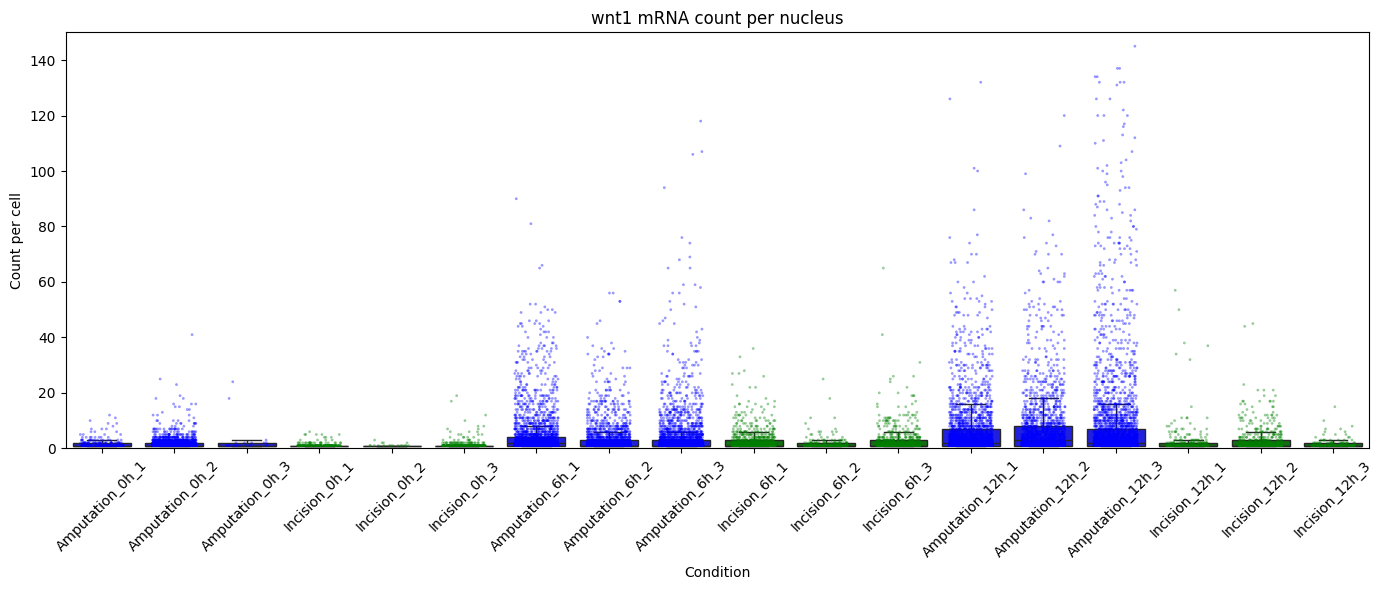

In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir("/Volumes/Backup Plus/Experiment_results/306_analysis_results_alter/Experiment")

# Read csv
df = pd.read_csv("306_output.csv")

# Convert wide -> long
df_long = df.melt(
    var_name="Condition",
    value_name="Value"
)

# Remove NaN values
df_long = df_long.dropna()

# Color by condition type
palette = {}

for cond in df_long["Condition"].unique():

    if "Incision" in cond:
        palette[cond] = "green"

    elif "Amputation" in cond:
        palette[cond] = "blue"

# Desired order
order = [
    'Amputation_0h_1',
    'Amputation_0h_2',
    'Amputation_0h_3',

    'Incision_0h_1',
    'Incision_0h_2',
    'Incision_0h_3',

    'Amputation_6h_1',
    'Amputation_6h_2',
    'Amputation_6h_3',

    'Incision_6h_1',
    'Incision_6h_2',
    'Incision_6h_3',

    'Amputation_12h_1',
    'Amputation_12h_2',
    'Amputation_12h_3',

    'Incision_12h_1',
    'Incision_12h_2',
    'Incision_12h_3'
]

# Keep only conditions that actually exist
order = [x for x in order if x in df_long["Condition"].unique()]

plt.figure(figsize=(14,6))

sns.boxplot(
    x="Condition",
    y="Value",
    data=df_long,
    order=order,
    showfliers=False,
    palette=palette
)

sns.stripplot(
    x="Condition",
    y="Value",
    data=df_long,
    order=order,
    hue="Condition",
    palette=palette,
    jitter=0.3,
    size=2,
    alpha=0.4,
    dodge=False
)

# Remove duplicate legend
ax = plt.gca()
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xticks(rotation=45)
plt.ylabel("Count per cell")
plt.title("wnt1 mRNA count per nucleus")
plt.ylim(0,150)

plt.tight_layout()

plt.savefig(
    "jittered_box_plot_of_mRNA_count_per_cell.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
# Getting all assignment results in nucleiing 
import glob
import os
import numpy as np
def find_all_files (folder_path, file_name):
    # Define the folder to search in
    folder_path = path
    # Find all matching files
    matching_filenames = glob.glob(os.path.join(folder_path, '**', file_name), recursive=True)
    
    # Print the list of matching files
    for file in matching_filenames:
        print(file)
    return matching_filenames

In [5]:
path = "/Volumes/Backup Plus/Experiment_results/332_notum_analysis"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Amputation_0h = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Amputation_0h.append(cells)
intensity_in_nuclei = sorted(find_all_files (path, "concatenated_intensity_in_nuclei.npy"))
Amputation_0h_intensity = []
for i in range(len(intensity_in_nuclei)):
    
    cells = np.load(intensity_in_nuclei[i])
    cells = cells[cells > 0]
    Amputation_0h_intensity.append(cells)

/Volumes/Backup Plus/Experiment_results/332_notum_analysis/Experiment/0h_Amputation/Image1/565/results/concatenated_spot_in_nuclei.npy
/Volumes/Backup Plus/Experiment_results/332_notum_analysis/Experiment/0h_Amputation/Image2/565/results/concatenated_spot_in_nuclei.npy
/Volumes/Backup Plus/Experiment_results/332_notum_analysis/Experiment/6h_Incision/Image1/565/results/concatenated_spot_in_nuclei.npy
/Volumes/Backup Plus/Experiment_results/332_notum_analysis/Experiment/6h_Incision/Image2/565/results/concatenated_spot_in_nuclei.npy
/Volumes/Backup Plus/Experiment_results/332_notum_analysis/Experiment/0h_Incision/Image1/565/results/concatenated_spot_in_nuclei.npy
/Volumes/Backup Plus/Experiment_results/332_notum_analysis/Experiment/0h_Incision/Image2/565/results/concatenated_spot_in_nuclei.npy
/Volumes/Backup Plus/Experiment_results/332_notum_analysis/Experiment/0h_Incision/Image3/565/results/concatenated_spot_in_nuclei.npy
/Volumes/Backup Plus/Experiment_results/332_notum_analysis/Experi

In [6]:
path = "/Volumes/Backup Plus/314_analysis_results/Experiment/0hr_Incision"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Incision_0h = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Incision_0h.append(cells)
intensity_in_nuclei = sorted(find_all_files (path, "concatenated_intensity_in_nuclei.npy"))
Incision_0h_intensity = []
for i in range(len(intensity_in_nuclei)):
    
    cells = np.load(intensity_in_nuclei[i])
    cells = cells[cells > 0]
    Incision_0h_intensity.append(cells)

In [7]:
path = "/Volumes/Backup Plus/306_analysis_results/Experiment/6hr_Incision"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Incision_6h = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Incision_6h.append(cells)
intensity_in_nuclei = sorted(find_all_files (path, "concatenated_intensity_in_nuclei.npy"))
Incision_6h_intensity = []
for i in range(len(intensity_in_nuclei)):
    
    cells = np.load(intensity_in_nuclei[i])
    cells = cells[cells > 0]
    Incision_6h_intensity.append(cells)

In [8]:
path = "/Volumes/Backup Plus/314_analysis_results/Experiment/6hr_Amputation"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Amputation_6h = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Amputation_6h.append(cells)
intensity_in_nuclei = sorted(find_all_files (path, "concatenated_intensity_in_nuclei.npy"))
Amputation_6h_intensity = []
for i in range(len(intensity_in_nuclei)):
    
    cells = np.load(intensity_in_nuclei[i])
    cells = cells[cells > 0]
    Amputation_6h_intensity.append(cells)

In [9]:
path = "/Volumes/Backup Plus/314_analysis_results/Experiment/12hr_Amputation"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Amputation_12h = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Amputation_12h.append(cells)
intensity_in_nuclei = sorted(find_all_files (path, "concatenated_intensity_in_nuclei.npy"))
Amputation_12h_intensity = []
for i in range(len(intensity_in_nuclei)):
    
    cells = np.load(intensity_in_nuclei[i])
    cells = cells[cells > 0]
    Amputation_12h_intensity.append(cells)

In [10]:
path = "/Volumes/Backup Plus/314_analysis_results/Experiment/12hr_Incision"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Incision_12h = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Incision_12h.append(cells)
intensity_in_nuclei = sorted(find_all_files (path, "concatenated_intensity_in_nuclei.npy"))
Incision_12h_intensity = []
for i in range(len(intensity_in_nuclei)):
    
    cells = np.load(intensity_in_nuclei[i])
    cells = cells[cells > 0]
    Incision_12h_intensity.append(cells)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Define the x-axis labels for each dataset
x_labels = ["0h Incision", '0h Amputation', '6h Incision', '6h Amputation', '12h Incision', '12h Amputation']

# Assuming your data arrays are already defined and concatenated
data_arrays = [np.concatenate(Incision_0h), np.concatenate(Amputation_0h), np.concatenate(Incision_6h),
               np.concatenate(Amputation_6h), np.concatenate(Incision_12h), np.concatenate(Amputation_12h)]

# Apply log transformation if there are extreme values
log_data_arrays = [np.log1p(data) for data in data_arrays]  # log1p handles zero values

# Perform t-tests only for the specified pairs and store results
pairs = [
    (2, 3),  # Incision 6h vs Amputation 6h
    (3, 5)   # Amputation 6h vs Amputation 12h
]

results = {}
for i, j in pairs:
    t_stat, p_value = stats.ttest_ind(data_arrays[i], data_arrays[j], equal_var=False)
    results[f"{x_labels[i]} vs {x_labels[j]}"] = p_value  # Store only p-values for plotting

# Plot setup
fig = plt.figure(figsize=(10, 6))

# Create violin plot
sns.violinplot(data=log_data_arrays, inner=None)

# Overlay the mean values using scatter directly on the violin plot
means = [np.mean(data) for data in log_data_arrays]
plt.scatter(x=np.arange(len(x_labels)), y=means, color='black', s=100, label='Means', zorder=5)  # Black points for means

# Add boxplot overlay
sns.boxplot(data=log_data_arrays, whis=np.inf, color='k', width=0.1)

# Customize the x-axis
plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels, rotation=45)

# Add labels and title
plt.title('Violin Plot of wnt1 Expression in BWM+ Cell Over Time (Log Scale)')
plt.ylabel('Log Values of wnt1 mRNA count in cell')

# Add t-test annotations for the specific comparisons
y_max = np.max([np.max(data) for data in log_data_arrays])  # Get the maximum y value for positioning
y_offset = 0.5  # Base offset for annotations
increment = 0.25  # Increment to space out p-values

for index, (key, p_value) in enumerate(results.items()):
    x1, x2 = pairs[index]  # Get the indices for the datasets being compared
    y_pos = y_max + y_offset + (increment * index)  # Adjust vertical position based on index

    # Calculate the average position between the two datasets for line placement
    avg_pos = (x1 + x2) / 2   # Center between the x-coordinates of the two datasets

    # Center the line between the two datasets
    plt.plot([x1 , x2], [y_pos, y_pos], color='k', linewidth=2)  # Centered line
    plt.text(avg_pos, y_pos + 0.10, f"p = {p_value:.5f}", ha='center')  # Add p-value text at average position

# Annotate mean values on the plot in the middle of the whole figure
mean_y_position = np.mean(means)  # Calculate the mean of the mean values for positioning
for i, mean in enumerate(means):
    plt.text(i, -0.05, f"{mean:.2f}", ha='center', color='black', fontsize=10)  # Annotate means

# Show plot with tight layout
plt.tight_layout()
plt.legend()
plt.show()
fig.savefig("incisionAmputationPlot.png")

ValueError: need at least one array to concatenate

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Define the x-axis labels for each dataset
x_labels = ["0h Incision", '0h Amputation', '6h Incision', '6h Amputation', '12h Incision', '12h Amputation']

# Assuming your data arrays are already defined and concatenated
data_arrays = [np.concatenate(Incision_0h_intensity), np.concatenate(Amputation_0h_intensity), np.concatenate(Incision_6h_intensity),
               np.concatenate(Amputation_6h_intensity), np.concatenate(Incision_12h_intensity), np.concatenate(Amputation_12h_intensity)]

# Apply log transformation if there are extreme values
log_data_arrays = [np.log1p(data) for data in data_arrays]  # log1p handles zero values

# Perform t-tests only for the specified pairs and store results
pairs = [
    (2, 3),  # Incision 6h vs Amputation 6h
    (3, 5)   # Amputation 6h vs Amputation 12h
]

results = {}
for i, j in pairs:
    t_stat, p_value = stats.ttest_ind(data_arrays[i], data_arrays[j], equal_var=False)
    results[f"{x_labels[i]} vs {x_labels[j]}"] = p_value  # Store only p-values for plotting

# Plot setup
fig = plt.figure(figsize=(10, 6))

# Create violin plot
sns.violinplot(data=log_data_arrays, inner=None)

# Overlay the mean values using scatter directly on the violin plot
means = [np.mean(data) for data in log_data_arrays]
plt.scatter(x=np.arange(len(x_labels)), y=means, color='black', s=100, label='Means', zorder=5)  # Black points for means

# Add boxplot overlay
sns.boxplot(data=log_data_arrays, whis=np.inf, color='k', width=0.1)

# Customize the x-axis
plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels, rotation=45)

# Add labels and title
plt.title('Violin Plot of wnt1 intensity in BWM+ Cell Over Time (Log Scale)')
plt.ylabel('Log Values of wnt1 mRNA count in cell')

# Add t-test annotations for the specific comparisons
y_max = np.max([np.max(data) for data in log_data_arrays])  # Get the maximum y value for positioning
y_offset = 0.5  # Base offset for annotations
increment = 0.25  # Increment to space out p-values

for index, (key, p_value) in enumerate(results.items()):
    x1, x2 = pairs[index]  # Get the indices for the datasets being compared
    y_pos = y_max + y_offset + (increment * index)  # Adjust vertical position based on index

    # Calculate the average position between the two datasets for line placement
    avg_pos = (x1 + x2) / 2   # Center between the x-coordinates of the two datasets

    # Center the line between the two datasets
    plt.plot([x1 , x2], [y_pos, y_pos], color='k', linewidth=2)  # Centered line
    plt.text(avg_pos, y_pos + 0.10, f"p = {p_value:.5f}", ha='center')  # Add p-value text at average position

# Annotate mean values on the plot in the middle of the whole figure
mean_y_position = np.mean(means)  # Calculate the mean of the mean values for positioning
for i, mean in enumerate(means):
    plt.text(i, -0.05, f"{mean:.2f}", ha='center', color='black', fontsize=10)  # Annotate means

# Show plot with tight layout
plt.tight_layout()
plt.legend()
plt.show()
fig.savefig("incisionAmputationPlot.png")

In [ ]:
import os
import pandas as pd
os.chdir('/Users/eliasguan/Downloads')

In [ ]:
data_dict = {
    "Incision_0h": Incision_0h,
    "Amputation_0h": Amputation_0h,
    "Incision_6h": Incision_6h,
    "Amputation_6h": Amputation_6h,
    "Incision_12h": Incision_12h,
    "Amputation_12h": Amputation_12h
}

# Create a dictionary to store columns
csv_data = {}

# Iterate over each condition and store separately
for key, arrays in data_dict.items():
    for i, arr in enumerate(arrays, start=1):
        csv_data[f"{key}_{i}"] = arr  # Unique column name

# Convert to DataFrame
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in csv_data.items()]))

# Save to CSV
df.to_csv("314_output.csv", index=False)

print("CSV file saved as output.csv!")

In [ ]:
data_dict = {
    "Incision_0h": Incision_0h_intensity,
    "Amputation_0h": Amputation_0h_intensity,
    "Incision_6h": Incision_6h_intensity,
    "Amputation_6h": Amputation_6h_intensity,
    "Incision_12h": Incision_12h_intensity,
    "Amputation_12h": Amputation_12h_intensity
}

# Create a dictionary to store columns
csv_data = {}

# Iterate over each condition and store separately
for key, arrays in data_dict.items():
    for i, arr in enumerate(arrays, start=1):
        csv_data[f"{key}_{i}"] = arr  # Unique column name

# Convert to DataFrame
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in csv_data.items()]))

# Save to CSV
df.to_csv("306_output_intensity.csv", index=False)

print("CSV file saved as output.csv!")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("306_output.csv")

# Convert to long format for seaborn
df_long = df.melt(var_name="Condition", value_name="Value")

palette = {
    'Incision_0h_1': 'blue',
    'Incision_0h_2': 'blue',
    'Incision_0h_3': 'blue',
    'Amputation_0h_1': 'red',
    'Amputation_0h_2': 'red',
    'Amputation_0h_3': 'red',
    'Incision_6h_1': 'green',
    'Incision_6h_3': "green",
    'Incision_6h_2': "green",
    'Amputation_6h_1': 'purple',
    'Amputation_6h_2': 'purple',
    'Amputation_6h_3': 'purple',
    'Incision_12h_1': 'violet',
    'Amputation_12h_1': 'cyan',
    'Amputation_12h_2': 'cyan',
    'Amputation_12h_3': 'cyan',
    'Incision_12h_2': 'violet',
    'Incision_12h_3': 'violet',
    'Amputation_12h': 'cyan', 
    'Amputation_6h' :'purple',
    'Incision_12h' :'violet',
    'Incision_6h' :'green',
    'Incision_0h' :'blue',
    'Amputation_0h':'red'
}
df_long['Group'] = df_long['Condition'].str.extract(r'([A-Za-z]+_\d+h)')[0]



plt.figure(figsize=(12, 6))

# Boxplot without grouping (keep individual conditions)
sns.boxplot(x="Condition", y="Value", data=df_long, showfliers=False, palette=palette)

# Jittered points with transparency and custom colors for each condition
sns.stripplot(x="Condition", y="Value", data=df_long, jitter=0.3, size=5, alpha=0.4, 
              hue="Condition", palette=palette, dodge=False, marker="o")

# Custom X-axis labels (show broader group names)
labels = df_long['Group'].unique()  # Get unique group names
plt.xticks(ticks=range(len(df_long['Condition'].unique())), labels=labels, rotation=45)

# Adjustments
plt.title("Jittered Box Plot of Conditions")
plt.xlabel("Condition")
plt.ylabel("Value")

# Show the plot
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("306_output.csv")

# Convert to long format for seaborn
df_long = df.melt(var_name="Condition", value_name="Value")

# Extract general group name (e.g., "Incision_0h", "Amputation_12h")
df_long['Group'] = df_long['Condition'].str.extract(r'([A-Za-z]+_\d+h)')[0]

# Dictionary to rename groups
rename_map = {
    'Incision_0h': 'Incision_0h_intensity',
    'Incision_6h': 'Incision_6h_intensity',
    'Incision_12h': 'Incision_12h_intensity',
    'Amputation_0h': 'Amputation_0h_intensity',
    'Amputation_6h': 'Amputation_6h_intensity',
    'Amputation_12h': 'Amputation_12h_intensity'
}

# Apply mapping to rename groups
df_long['Group'] = df_long['Group'].map(rename_map)

# Define custom palette
palette = {
    'Incision_0h_1': 'blue', 'Incision_0h_2': 'blue', 'Incision_0h_3': 'blue',
    'Amputation_0h_1': 'red', 'Amputation_0h_2': 'red', 'Amputation_0h_3': 'red',
    'Incision_6h_1': 'green', 'Incision_6h_2': 'green', 'Incision_6h_3': 'green',
    'Amputation_6h_1': 'purple', 'Amputation_6h_2': 'purple', 'Amputation_6h_3': 'purple',
    'Incision_12h_1': 'violet', 'Incision_12h_2': 'violet', 'Incision_12h_3': 'violet',
    'Amputation_12h_1': 'cyan', 'Amputation_12h_2': 'cyan', 'Amputation_12h_3': 'cyan',
    'Amputation_12h': 'cyan', 'Amputation_6h': 'purple', 'Incision_12h': 'violet',
    'Incision_6h': 'green', 'Incision_0h': 'blue', 'Amputation_0h': 'red'
}

plt.figure(figsize=(12, 6))

# Boxplot without grouping (keep individual conditions)
sns.boxplot(x="Condition", y="Value", data=df_long, showfliers=False, palette=palette)

# Jittered points with transparency and custom colors for each condition
sns.stripplot(x="Condition", y="Value", data=df_long, jitter=0.3, size=5, alpha=0.4, 
              hue="Condition", palette=palette, dodge=False, marker="o")

# Custom X-axis labels (show broader group names)
labels = df_long['Group'].unique()  # Get unique group names
plt.xticks(ticks=range(len(df_long['Condition'].unique())), labels=labels, rotation=45)

# Adjustments
plt.title("Jittered Box Plot of Conditions")
plt.xlabel("Condition")
plt.ylabel("Value")

# Show the plot
plt.show()


In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/0h_Amputation"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Amputation_0h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Amputation_0h_nuclei.append(cells)



In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/0h_Incision"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Incision_0h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Incision_0h_nuclei.append(cells)

In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/6h_Amputation"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Amputation_6h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Amputation_6h_nuclei.append(cells)

In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/6h_Incision"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Incision_6h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Incision_6h_nuclei.append(cells)

In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/12h_Amputation"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Amputation_12h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Amputation_12h_nuclei.append(cells)

In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/12h_Incision"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_in_nuclei.npy"))
Incision_12h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    Incision_12h_nuclei.append(cells)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Define the x-axis labels for each dataset
x_labels = ["0h Incision", '0h Amputation', '6h Incision', '6h Amputation', '12h Incision', '12h Amputation']

# Assuming your data arrays are already defined and concatenated
data_arrays = [np.concatenate(Incision_0h_nuclei), np.concatenate(Amputation_0h_nuclei), np.concatenate(Incision_6h_nuclei),
               np.concatenate(Amputation_6h_nuclei), np.concatenate(Incision_12h_nuclei), np.concatenate(Amputation_12h_nuclei)]

# Apply log transformation if there are extreme values
log_data_arrays = [np.log1p(data) for data in data_arrays]  # log1p handles zero values

# Perform t-tests only for the specified pairs and store results
pairs = [
    (2, 3),  # Incision 6h vs Amputation 6h
    (3, 5)   # Amputation 6h vs Amputation 12h
]

results = {}
for i, j in pairs:
    t_stat, p_value = stats.ttest_ind(data_arrays[i], data_arrays[j], equal_var=False)
    results[f"{x_labels[i]} vs {x_labels[j]}"] = p_value  # Store only p-values for plotting

# Plot setup
fig = plt.figure(figsize=(10, 6))

# Create violin plot
sns.violinplot(data=log_data_arrays, inner=None)

# Overlay the mean values using scatter directly on the violin plot
means = [np.mean(data) for data in log_data_arrays]
plt.scatter(x=np.arange(len(x_labels)), y=means, color='black', s=100, label='Means', zorder=5)  # Black points for means

# Add boxplot overlay
sns.boxplot(data=log_data_arrays, whis=np.inf, color='k', width=0.1)

# Customize the x-axis
plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels, rotation=45)

# Add labels and title
plt.title('Violin Plot of wnt1 Expression in Nucleus Over Time (Log Scale)')
plt.ylabel('Log Values of wnt1 mRNA count in Cell')

# Add t-test annotations for the specific comparisons
y_max = np.max([np.max(data) for data in log_data_arrays])  # Get the maximum y value for positioning
y_offset = 0.5  # Base offset for annotations
increment = 0.25  # Increment to space out p-values

for index, (key, p_value) in enumerate(results.items()):
    x1, x2 = pairs[index]  # Get the indices for the datasets being compared
    y_pos = y_max + y_offset + (increment * index)  # Adjust vertical position based on index

    # Calculate the average position between the two datasets for line placement
    avg_pos = (x1 + x2) / 2   # Center between the x-coordinates of the two datasets

    # Center the line between the two datasets
    plt.plot([x1 , x2], [y_pos, y_pos], color='k', linewidth=2)  # Centered line
    plt.text(avg_pos, y_pos + 0.10, f"p = {p_value:.5f}", ha='center')  # Add p-value text at average position

# Annotate mean values on the plot in the middle of the whole figure
mean_y_position = np.mean(means)  # Calculate the mean of the mean values for positioning
for i, mean in enumerate(means):
    plt.text(i, 0.2, f"{mean:.2f}", ha='center', color='black', fontsize=10)  # Annotate means

# Show plot with tight layout
plt.tight_layout()
plt.legend()
plt.show()
fig.savefig("incisionAmputationPlot_in_nuclei.png")

In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/0h_Amputation"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_counterstain.npy"))
counterstain_Amputation_0h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    counterstain_Amputation_0h_nuclei.append(cells)


In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/0h_Incision"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_counterstain.npy"))
counterstain_Incision_0h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    counterstain_Incision_0h_nuclei.append(cells)


In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/6h_Amputation"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_counterstain.npy"))
counterstain_Amputation_6h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    counterstain_Amputation_6h_nuclei.append(cells)

In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/6h_Incision"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_counterstain.npy"))
counterstain_Incision_6h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    counterstain_Incision_6h_nuclei.append(cells)

In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/12h_Amputation"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_counterstain.npy"))
counterstain_Amputation_12h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    counterstain_Amputation_12h_nuclei.append(cells)

In [ ]:
path = "/Users/eliasguan/Desktop/EG_0920_Test_wnt1_incision_amputation/Experiment_dataset/Experiment/12h_Incision"
spot_in_nuclei = sorted(find_all_files (path, "concatenated_spot_counterstain.npy"))
counterstain_Incision_12h_nuclei = []
for i in range(len(spot_in_nuclei)):
    
    cells = np.load(spot_in_nuclei[i])
    cells = cells[cells > 0]
    counterstain_Incision_12h_nuclei.append(cells)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Define the x-axis labels for each dataset
x_labels = ["0h Incision", '0h Amputation', '6h Incision', '6h Amputation', '12h Incision', '12h Amputation']

# Assuming your data arrays are already defined and concatenated
data_arrays = [np.concatenate(counterstain_Incision_0h_nuclei), np.concatenate(counterstain_Amputation_0h_nuclei), np.concatenate(counterstain_Incision_6h_nuclei),
               np.concatenate(counterstain_Amputation_6h_nuclei), np.concatenate(counterstain_Incision_12h_nuclei), np.concatenate(counterstain_Amputation_12h_nuclei)]

# Apply log transformation if there are extreme values
log_data_arrays = [np.log1p(data) for data in data_arrays]  # log1p handles zero values

# Perform t-tests only for the specified pairs and store results
pairs = [
    (2, 3),  # Incision 6h vs Amputation 6h
    (3, 5)   # Amputation 6h vs Amputation 12h
]

results = {}
for i, j in pairs:
    t_stat, p_value = stats.ttest_ind(data_arrays[i], data_arrays[j], equal_var=False)
    results[f"{x_labels[i]} vs {x_labels[j]}"] = p_value  # Store only p-values for plotting

# Plot setup
fig = plt.figure(figsize=(10, 6))

# Create violin plot
sns.violinplot(data=log_data_arrays, inner=None)

# Overlay the mean values using scatter directly on the violin plot
means = [np.mean(data) for data in log_data_arrays]
plt.scatter(x=np.arange(len(x_labels)), y=means, color='black', s=100, label='Means', zorder=5)  # Black points for means

# Add boxplot overlay
sns.boxplot(data=log_data_arrays, whis=np.inf, color='k', width=0.1)

# Customize the x-axis
plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels, rotation=45)

# Add labels and title
plt.title('Violin Plot of BWM Expression Over Time (Log Scale)')
plt.ylabel('Log Values of BWM Spot count')

# Add t-test annotations for the specific comparisons
y_max = np.max([np.max(data) for data in log_data_arrays])  # Get the maximum y value for positioning
y_offset = 0.5  # Base offset for annotations
increment = 0.25  # Increment to space out p-values

for index, (key, p_value) in enumerate(results.items()):
    x1, x2 = pairs[index]  # Get the indices for the datasets being compared
    y_pos = y_max + y_offset + (increment * index)  # Adjust vertical position based on index

    # Calculate the average position between the two datasets for line placement
    avg_pos = (x1 + x2) / 2   # Center between the x-coordinates of the two datasets

    # Center the line between the two datasets
    plt.plot([x1 , x2], [y_pos, y_pos], color='k', linewidth=2)  # Centered line
    plt.text(avg_pos, y_pos + 0.10, f"p = {p_value:.5f}", ha='center')  # Add p-value text at average position

# Annotate mean values on the plot in the middle of the whole figure
mean_y_position = np.mean(means)  # Calculate the mean of the mean values for positioning
for i, mean in enumerate(means):
    plt.text(i, 0.2, f"{mean:.2f}", ha='center', color='black', fontsize=10)  # Annotate means

# Show plot with tight layout
plt.tight_layout()
plt.legend()
plt.show()
fig.savefig("BWMPlot_in_nuclei.png")

In [ ]:
filepath = "/Users/eliasguan/Desktop/EG_GRC_Poster/Lab Meeting Presentation and Progress/Report To Chris 103024/Example Image/Nuclei_labesl.tif"

In [ ]:
import tifffile
nuclei = tifffile.imread(filepath)
os.chdir(os.path.dirname(filepath))

In [ ]:
from skimage import segmentation
expanded = segmentation.expand_labels(nuclei,20)

In [ ]:
tifffile.imwrite("expanded_example_nuclei.tif", expanded, photometric = "minisblack")

In [ ]:
os.getcwd()